In [1]:
import graph_style as gs
import fig_helper as fh
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

gs.set_graph_style(1)

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
C:\Users\webbd\AppData\Local\Temp\ipykernel_14096\1501776561.py:12: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(x_fit, P_fit[0], color=gs.get_color(1), alpha=gs.get_alpha(), linestyle="-", label="$\mathcal{P}_{SS}$")
C:\Users\webbd\AppData\Local\Temp\ipykernel_14096\1501776561.py:13: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(x_fit, P_fit[3], color="#017517", alpha=gs.get_alpha(), linestyle="-", label="$\mathcal{P}_{FF}$")
C:\Users\webbd\AppData\Local\Temp\ipykernel_14096\1501776561.py:15: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(x_fit, P0110_fit, color=gs.get_color(3), alpha=gs.get_alpha(), linestyle="-", label="$\mathcal{P}_{SF}+P_{FS}$")


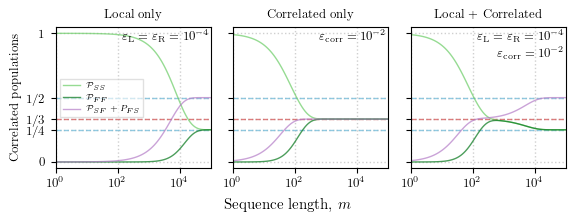

In [ ]:
def plot_data_fit(ax, m, popt):
    x_min = 1
    model_func = m.model
    x_max = 1e5 
    reshape_fac = 4
    ax.hlines(0.25, x_min, x_max, color=gs.get_color(5), linestyle="--", alpha=0.8)
    ax.hlines(0.5, x_min, x_max, color=gs.get_color(5), linestyle="--", alpha=0.8)
    ax.hlines(0.333, x_min, x_max, color=gs.get_color(2), linestyle="--", alpha=0.8)

    x_fit = np.logspace(np.log10(x_min), np.log10(x_max), 100)        
    P_fit = model_func(x_fit, *popt).reshape(reshape_fac, -1)
    ax.plot(x_fit, P_fit[0], color=gs.get_color(1), alpha=gs.get_alpha(), linestyle="-", label="$\mathcal{P}_{SS}$")
    ax.plot(x_fit, P_fit[3], color="#017517", alpha=gs.get_alpha(), linestyle="-", label="$\mathcal{P}_{FF}$")
    P0110_fit = P_fit[1] + P_fit[2]
    ax.plot(x_fit, P0110_fit, color=gs.get_color(3), alpha=gs.get_alpha(), linestyle="-", label="$\mathcal{P}_{SF}+P_{FS}$")
    ax.set_ylabel("Populations")
    ax.legend(loc="upper right")
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(x_min, x_max)
    ax.set_xscale("log")

m = fh.SO3Model()
fig_width = gs.get_fig_width()
fig_height = gs.get_fig_width()/2.5

fig, axs = plt.subplots(1, 3, figsize=(fig_width, fig_height), sharey=True)

x_min = 1

popt = [0.0, 0.0001, 0.0001, 0.0]
plot_data_fit(axs[0], m, popt)

popt = [0.01, 0.000, 0.000, 0.0]
plot_data_fit(axs[1], m, popt)

popt = [0.01, 0.0001, 0.0001, 0.0]
plot_data_fit(axs[2], m, popt)

for ax in axs:
    ax.set_yticks([0, 1/4, 1/3, 1/2, 1.0])
    ax.set_yticklabels(["0", r"$1/4$",r"$1/3$", r"$1/2$", "1"])
    ax.set_ylabel("")
    ax.legend().set_visible(False)
axs[0].legend().set_visible(True)
axs[0].legend(loc="best")
axs[0].set_ylabel("Correlated populations")
# raise supxlabel
fig.supxlabel("Sequence length, $m$", y=0.075)
axs[0].set_title(r"Local only")
axs[1].set_title(r"Correlated only")
axs[2].set_title(r"Local + Correlated")
# error mag text in upper right
axs[0].text(0.99, 0.97, r"$\varepsilon_\mathrm{L} =\varepsilon_\mathrm{R} = 10^{-4}$", transform=axs[0].transAxes, fontsize=9, verticalalignment='top', horizontalalignment='right')
axs[1].text(0.99, 0.97, r"$\varepsilon_\mathrm{corr} = 10^{-2}$", transform=axs[1].transAxes, fontsize=9, verticalalignment='top', horizontalalignment='right')
axs[2].text(0.99, 0.97, r"$\varepsilon_\mathrm{L} =\varepsilon_\mathrm{R} = 10^{-4}$", transform=axs[2].transAxes, fontsize=9, verticalalignment='top', horizontalalignment='right')
axs[2].text(0.99, 0.85, r"$\varepsilon_\mathrm{corr} = 10^{-2}$", transform=axs[2].transAxes, fontsize=9, verticalalignment='top', horizontalalignment='right')
plt.tight_layout()
f_path = "..\\..\\pdf_figure\\ch4\\f2_asymptotes.pdf"
plt.savefig(f_path, bbox_inches = "tight")

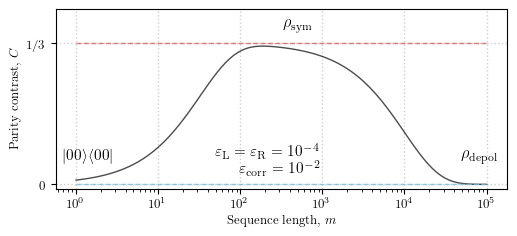

In [51]:
x_min = 1
x_max = 1e5
sim_line = np.logspace(np.log10(x_min), np.log10(x_max), 100)        
popt_par = [0.01, 0.0001]
fitted_parity_par = m.parity_model(sim_line, *popt_par)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))
plt.xscale("log")
plt.plot(sim_line, fitted_parity_par, color="black", alpha=gs.get_alpha(), linestyle="-")
plt.hlines(1/3, x_min, x_max, color=gs.get_color(2), linestyle="--", alpha=0.8)
plt.hlines(0, x_min, x_max, color=gs.get_color(5), linestyle="--", alpha=0.8)
plt.ylabel("Parity contrast, $C$")
plt.ylim(-0.01, 1/3+0.08)
plt.yticks([0, 1/3], ["0", r"$1/3$"])
plt.xlabel("Sequence length, $m$")
# label peak at m=10^2 and C = 1/3, \rho_sym
plt.text(5*10**2, 1/3+0.06, r"$\rho_\mathrm{sym}$", fontsize=12, verticalalignment='top', horizontalalignment='center')
# # label start, m=0, C = 0, \ket{00}\bra{00}
plt.text(1.4, 0.05, r"$|00\rangle\langle 00|$", fontsize=11, verticalalignment='bottom', horizontalalignment='center')
# # label end, m=10^5, C = 0, \rho_depol
plt.text(8*10**4, 0.05, r"$\rho_\mathrm{depol}$", fontsize=12, verticalalignment='bottom', horizontalalignment='center')
plt.text(9*10**2, 0.06, r"$\varepsilon_\mathrm{L} =\varepsilon_\mathrm{R} = 10^{-4}$", fontsize=11, verticalalignment='bottom', horizontalalignment='right')
plt.text(9*10**2, 0.02, r"$\varepsilon_\mathrm{corr} = 10^{-2}$", fontsize=11, verticalalignment='bottom', horizontalalignment='right')

f_path = "..\\..\\pdf_figure\\ch4\\par_asymptotes.pdf"
plt.savefig(f_path, bbox_inches = "tight")
